# Split Datasets

Split dataset to Train/Validation/Test sets

## A. Overview

To avoid Data Leakage, Train/Validation/Test set should contain different events.

Event type that have
- 03 events, can be in all set 
- 02 events, skip Validation set
- 01 event, can only in Train set

Random split to Train, Validation and Test sets:

- `event_type` with value **disaster** is exception, no specified defined event in the type.
- `event_name` with values **Landslides Worldwide**, **disaster_events** and **NaN** (from **eyewitness_messages** and **disasters_on_social_media** dataset)

## B. Load Dataset

In [1]:
from pathlib import Path
import csv

from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

import configuration
from src import dataset_settings

# from dotenv import load_dotenv
# load_dotenv()

df_relevant = pd.read_csv('../data/normalized/unified_relevant_dataset_normalized.csv')

# processed in final part
# df_relevant_bertweet = pd.read_csv('../data/normalized/unified_relevant_dataset_bertweet_normalized.csv')

/var/folders/yh/9qq7z2f14f14bdj_1k2673700000gn/T/ipykernel_32617/3433716111.py:14: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_relevant = pd.read_csv('../data/normalized/unified_relevant_dataset_normalized.csv')


## C. Relevant

### C.1. Event types that has at least 03 events

Text(0.5, 1.0, 'Number of event_name entries for each event_type for relevant-labeled tweets')

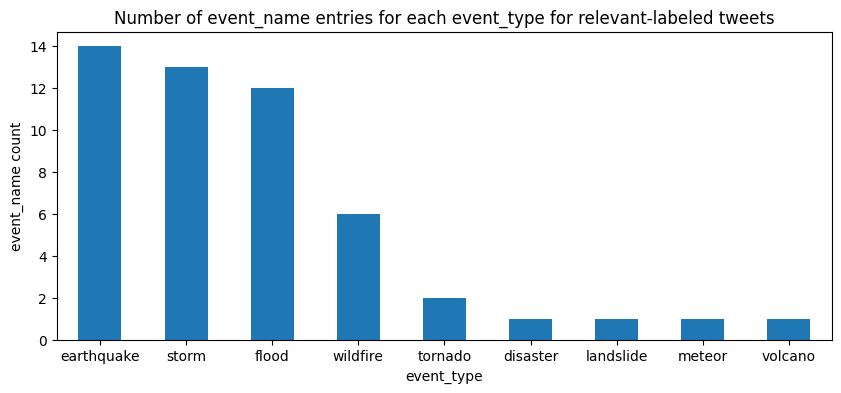

In [2]:
event_name_count_by_type = (
    df_relevant.groupby('event_type')['event_name']
      .nunique()
      .sort_values(ascending=False)
)

ax = event_name_count_by_type.plot(kind='bar', figsize=(10, 4), rot=0)
ax.set_xlabel('event_type')
ax.set_ylabel('event_name count')
ax.set_title('Number of event_name entries for each event_type for relevant-labeled tweets')

| event type | Train | Validation | Test | Note |
| --- | --- | --- | --- | --- |
| earthquake | ✅ | ✅ | ✅ | |
| storm | ✅ | ✅ | ✅ | |
| flood | ✅ | ✅ | ✅ | |
| wildfire | ✅ | ✅ | ✅ | |
| tornado | ✅ | 🚫 | ✅ | |
| disaster | ✅ | ✅ | ✅ | unknow disaster, random split |
| landslide | ✅ | ✅ | ✅ | worldwide, random split |
| meteor | ✅ | 🚫 | 🚫 | |
| volcano | ✅ | 🚫 | 🚫 | |

In [3]:
counting = 0
gte_three_events = ['earthquake', 'storm', 'flood', 'wildfire']
for event_type in gte_three_events:
    count_by_event = df_relevant[df_relevant['event_type'] == event_type].groupby('event_name')['tweet_id'].count()
    print(f"Event type: {event_type}")
    print(count_by_event)
    print(count_by_event.sum())
    gte_three_events += list(count_by_event.index)
    counting += count_by_event.sum()
    print('- - - - - -')

print(f"Total tweets: {counting}")

Event type: earthquake
event_name
2012 Costa Rica Earthquake        1177
2012 Guatemala Earthquake          931
2012 Italy Earthquakes             929
2013 Bohol Earthquake              886
2013 Pakistan Earthquake          1881
2014 California Earthquake        1871
2014 Chile Earthquake             2360
2015 Nepal Earthquake            13961
2016 Ecuador Earthquake           5728
2016 Italy Earthquake             1201
2016 Kaikoura Earthquake          2195
2017 Iraq-Iran Earthquake          413
2017 Puebla Mexico Earthquake     3025
2019 Pakistan Earthquake          1958
Name: tweet_id, dtype: int64
38516
- - - - - -
Event type: storm
event_name
2012 Sandy Hurricane                 9423
2012 Typhoon Pablo                    928
2013 Typhoon Yolanda                  908
2014 Hurricane Odile Mexico          1419
2014 Philippines Typhoon Hagupit    11390
2015 Cyclone Pam                     2601
2016 Hurricane Matthew               1654
2017 Hurricane Harvey               11994
2017 Hur

In [4]:
# manually picking the events each sets
relevant_validation_events = [
    "2012 Costa Rica Earthquake",
    "2012 Guatemala Earthquake",
    "2012 Italy Earthquakes",
    "2015 Cyclone Pam",
    "2016 Hurricane Matthew",
    "2018 Hurricane Florence",
    "2013 Colorado Floods",
    "2013 Manila Floods",
    "2017 Sri Lanka Floods",
    "2012 Colorado Wildfires",
]

relevant_test_events = [
    "2013 Bohol Earthquake",
    "2016 Italy Earthquake",
    "2017 Iraq-Iran Earthquake",
    "2012 Typhoon Pablo",
    "2013 Typhoon Yolanda",
    "2014 Hurricane Odile Mexico",
    "2019 Cyclone Idai",
    "2012 Philippines Floods",
    "2013 Sardinia Floods",
    "2018 Maryland Floods",
    "2013 Australia Bushfire",
]

df_relevant_train = df_relevant[
    ~df_relevant["event_name"].isin(relevant_validation_events + relevant_test_events)
    & df_relevant["event_type"].isin(gte_three_events)
]

df_relevant_validation = df_relevant[
    df_relevant["event_name"].isin(relevant_validation_events)
]

df_relevant_test = df_relevant[df_relevant["event_name"].isin(relevant_test_events)]

In [5]:
print(len(df_relevant_train))
print(len(df_relevant_validation))
print(len(df_relevant_test))

155253
17837
13259


### C.2. Event types that has 02 events

Only `tornado`

In [6]:
print(
    df_relevant[df_relevant["event_type"] == "tornado"]
    .groupby("event_name")["tweet_id"]
    .count()
)

df_relevant_train = pd.concat(
    [
        df_relevant_train,
        df_relevant[df_relevant["event_name"] == "2013 Oklahoma Tornado"],
    ]
)

df_relevant_test = pd.concat(
    [df_relevant_test, df_relevant[df_relevant["event_name"] == "2011 Joplin tornado"]]
)

event_name
2011 Joplin tornado      4123
2013 Oklahoma Tornado    9307
Name: tweet_id, dtype: int64


In [7]:
print(len(df_relevant_train)) # 141429 + 9307 = 150736
print(len(df_relevant_validation)) # 15506, no change
print(len(df_relevant_test)) # 13259 + 4123 = 17382

164560
17837
17382


### C.3. Event types that has 01 events

`meteor`, and `volcano`

In [8]:
single_event_types = ['meteor', 'volcano']
print(len(df_relevant[df_relevant['event_type'].isin(single_event_types)]))
df_relevant_train = pd.concat([df_relevant_train,
    df_relevant[df_relevant['event_type'].isin(single_event_types)]
])
print(len(df_relevant_train)) # 150736 + 1571 = 152307

1571
166131


### C.4. Random split to Train, Validation and Test sets

- `event_type` with value **disaster** and **landslide**
- `event_name` with values **Landslides Worldwide**, **disaster_events** and **NaN**

In [9]:
undefined_mask = (
    df_relevant["event_type"].isin(["disaster", "landslide"])
    | df_relevant["event_name"].isna()
    | df_relevant["event_name"].isin(["Landslides Worldwide", "disaster_events"])
)

df_undefined_train, df_undefined_temp = train_test_split(
    df_relevant[undefined_mask],
    test_size=0.3,
    random_state=42,
    stratify=df_relevant[undefined_mask]["relevant"],
)
df_undefined_validation, df_undefined_test = train_test_split(
    df_undefined_temp, test_size=0.5, random_state=42, stratify=df_undefined_temp["relevant"]
)
print(len(df_undefined_train))
print(len(df_undefined_validation))
print(len(df_undefined_test))

39846
8539
8539


In [10]:
df_relevant_train = pd.concat([df_relevant_train, df_undefined_train])
df_relevant_validation = pd.concat([df_relevant_validation, df_undefined_validation])
df_relevant_test = pd.concat([df_relevant_test, df_undefined_test])

In [11]:
print(len(df_relevant_train)) # 152307 + 39846 = 192153
print(len(df_relevant_validation))  # 17382 + 8539 = 26376
print(len(df_relevant_test))  # 17382 + 8539 = 25921

# ration between train, validation, and test sets
total = len(df_relevant_train) + len(df_relevant_validation) + len(df_relevant_test)
print(f"Train: {len(df_relevant_train) / total:.2%}")
print(f"Validation: {len(df_relevant_validation) / total:.2%}")
print(f"Test: {len(df_relevant_test) / total:.2%}")

205977
26376
25921
Train: 79.75%
Validation: 10.21%
Test: 10.04%


In [12]:
df_relevant_train[["tweet_text", "relevant"]].sample(
    frac=1, random_state=42
).to_csv(
    "../data/splited/relevant_normalized_train.csv", index=False, quoting=csv.QUOTE_ALL
)

df_relevant_validation[["tweet_text", "relevant"]].sample(
    frac=1, random_state=42
).to_csv(
    "../data/splited/relevant_normalized_validation.csv", index=False,quoting=csv.QUOTE_ALL,
)

df_relevant_test[["tweet_text", "relevant"]].sample(
    frac=1, random_state=42
).to_csv(
    "../data/splited/relevant_normalized_test.csv", index=False, quoting=csv.QUOTE_ALL
)

### C.5. Check class ration

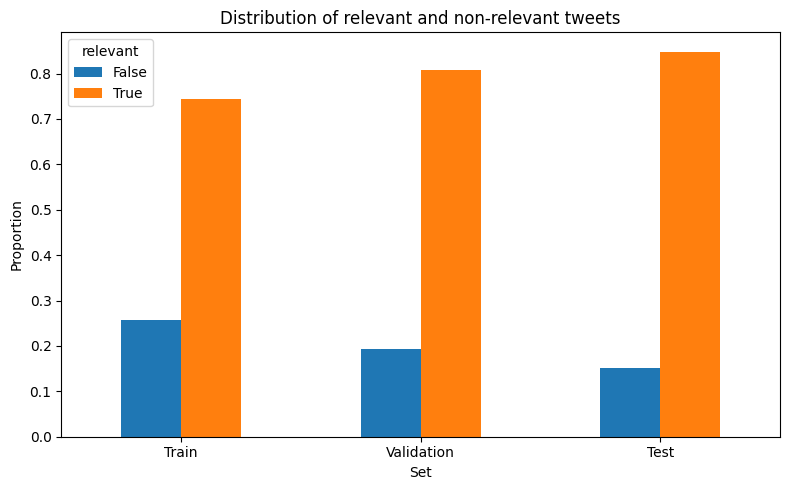

In [13]:
class_dist = pd.DataFrame({
    "Train": df_relevant_train["relevant"].value_counts(normalize=True).sort_index(),
    "Validation": df_relevant_validation["relevant"].value_counts(normalize=True).sort_index(),
    "Test": df_relevant_test["relevant"].value_counts(normalize=True).sort_index(),
}).fillna(0)

ax = class_dist.T.plot(kind="bar", figsize=(8, 5), rot=0)
ax.set_xlabel("Set")
ax.set_ylabel("Proportion")
ax.set_title("Distribution of relevant and non-relevant tweets")
ax.legend(title="relevant")
plt.tight_layout()
plt.show()

### C.6. Split BERTweet sets

In [14]:
df_relevant_bertweet = pd.read_csv(
    "../data/normalized/unified_relevant_dataset_bertweet_normalized.csv"
)

df_relevant_bertweet[df_relevant_bertweet["tweet_id"].isin(df_relevant_train["tweet_id"])][
    ["tweet_text", "relevant"]
].to_csv(
    "../data/splited/relevant_bertweet_normalized_train.csv",
    index=False,
    quoting=csv.QUOTE_ALL,
)
df_relevant_bertweet[df_relevant_bertweet["tweet_id"].isin(df_relevant_validation["tweet_id"])][
    ["tweet_text", "relevant"]
].to_csv(
    "../data/splited/relevant_bertweet_normalized_validation.csv",
    index=False,
    quoting=csv.QUOTE_ALL,
)
df_relevant_bertweet[df_relevant_bertweet["tweet_id"].isin(df_relevant_test["tweet_id"])][
    ["tweet_text", "relevant"]
].to_csv(
    "../data/splited/relevant_bertweet_normalized_test.csv",
    index=False,
    quoting=csv.QUOTE_ALL,
)

/var/folders/yh/9qq7z2f14f14bdj_1k2673700000gn/T/ipykernel_32617/518292106.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_relevant_bertweet = pd.read_csv(
